<a href="https://colab.research.google.com/github/iketimkov/python/blob/main/ML/titanic/titanic_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Predicting survival from the Titanic disaster
# using multiple models:
# 1 -
# 2 -
# 3 -

# Data from Kaggle
# https://www.kaggle.com/competitions/titanic/data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

In [ ]:
# Read in training and test data
file_path = ''
df = pd.read_csv(file_path+'train.csv')
df_test = pd.read_csv(file_path+'test.csv')


* survival |	Survival	0 = No, 1 = Yes
* pclass |	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
* sex |	Sex
* Age |	Age in years
* sibsp |	# of siblings / spouses aboard the Titanic
* parch |	# of parents / children aboard the Titanic
* ticket |	Ticket number
* fare |	Passenger fare
* cabin |	Cabin number
* embarked |	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

**Variable Notes**
* pclass: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

* age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

* sibsp: The dataset defines family relations in this way...
Sibling = brother, sister, stepbrother, stepsister
Spouse = husband, wife (mistresses and fiancés were ignored)

* parch: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print('Duplicates: ',df.duplicated().sum())
print('Missing Values: \n',df.isna().sum())

Duplicates:  0
Missing Values: 
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


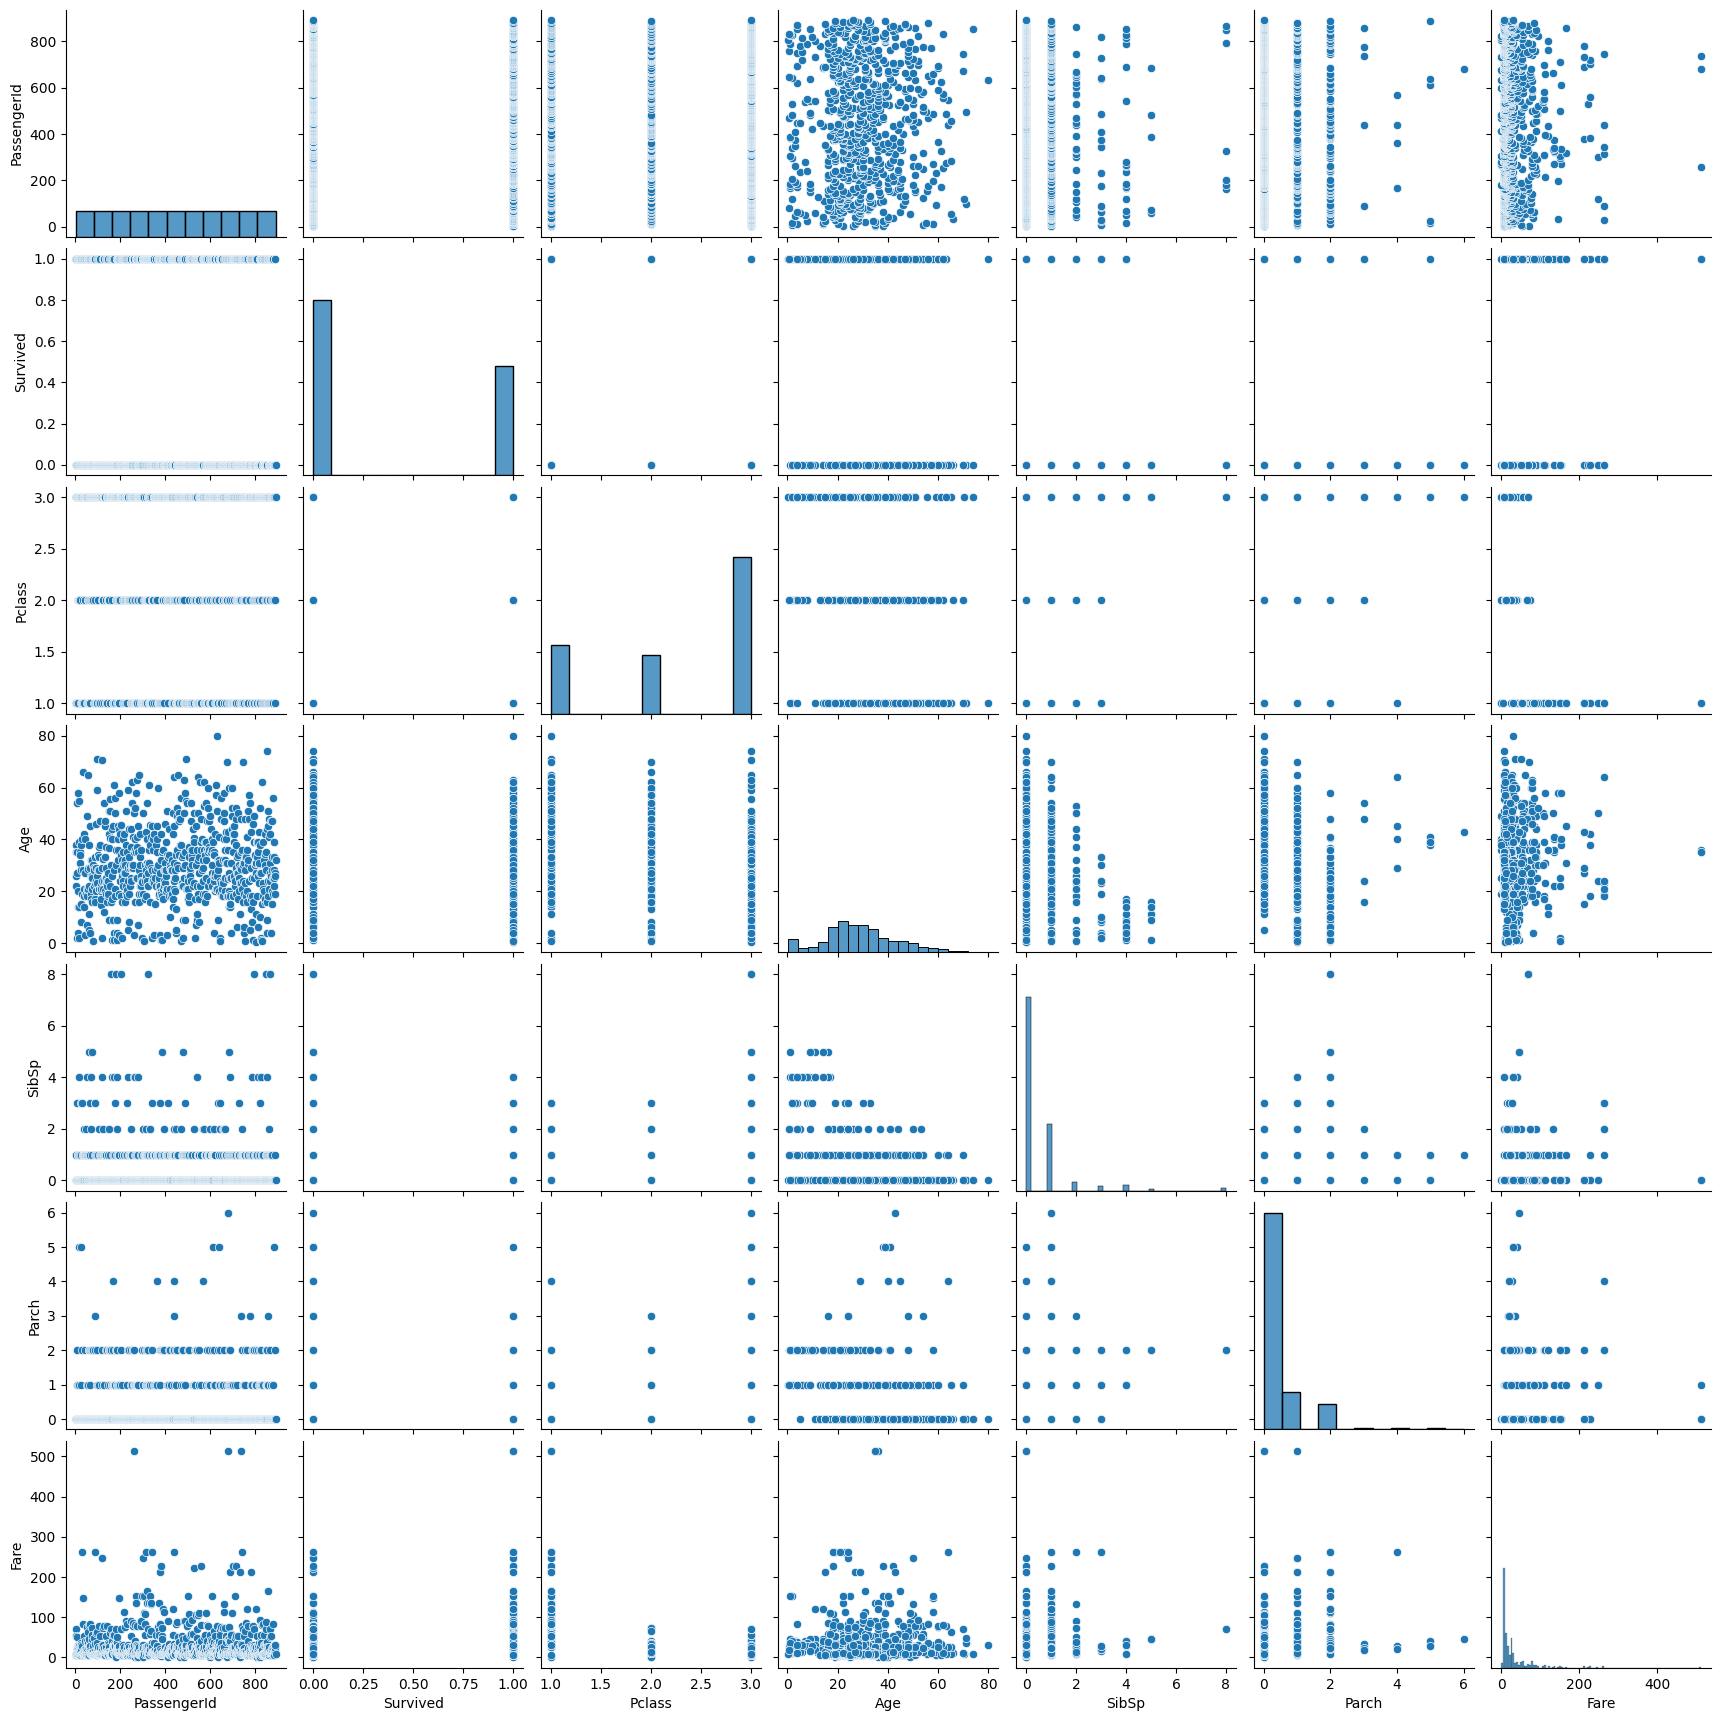

In [ ]:
# Check for any clear correlations
sns.pairplot(df)

In [ ]:
# Difference in population summary statistics
df[df['Survived']==1].describe() - df[df['Survived']==0].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,-207.000000,-207.0,-207.000000,-134.000000,-207.000000,-207.000000,-207.000000
mean,-2.647972,1.0,-0.581584,-2.282490,-0.080050,0.135222,26.277521
std,-8.281629,0.0,0.127516,0.778842,-0.579712,-0.051454,35.208792
min,1.000000,1.0,0.000000,-0.580000,0.000000,0.000000,0.000000
25%,39.750000,1.0,-1.000000,-2.000000,0.000000,0.000000,4.620800
50%,-15.500000,1.0,-1.000000,0.000000,0.000000,0.000000,15.500000
75%,-23.500000,1.0,0.000000,-3.000000,0.000000,1.000000,31.000000
max,-1.000000,1.0,0.000000,6.000000,-4.000000,-1.000000,249.329200


In [ ]:
df[df['Survived']==0].describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,549.000000,549.0,549.000000,424.000000,549.000000,549.000000,549.000000
mean,447.016393,0.0,2.531876,30.626179,0.553734,0.329690,22.117887
std,260.640469,0.0,0.735805,14.172110,1.288399,0.823166,31.388207
min,1.000000,0.0,1.000000,1.000000,0.000000,0.000000,0.000000
25%,211.000000,0.0,2.000000,21.000000,0.000000,0.000000,7.854200
50%,455.000000,0.0,3.000000,28.000000,0.000000,0.000000,10.500000
75%,675.000000,0.0,3.000000,39.000000,1.000000,0.000000,26.000000
max,891.000000,0.0,3.000000,74.000000,8.000000,6.000000,263.000000


In [ ]:
# Copy the original data for training
# Create new features
# Remove redundant/irrelevant columns

def clean_titanic_data(df,dropna=False):
  X = df.copy()
  if dropna:
    X = X.dropna()

  # Assign y if there is a Survived column
  if 'Survived' in X.columns:
    y = X[]

  # Simplify cabin data to a yes/no (1/0)
  X['Cabin_bool'] = X['Cabin'].notna().astype(int)

  # Prep Pclass for readable one-hot encoding
  X['Pclass'] = X['Pclass'].map({1: 'Upper', 2: 'Middle', 3: 'Lower'})

  # Separate Ticket to categories
  # Get first word of Ticket
  X['Ticket Type'] = X['Ticket'].str.split(' ').str[0]
  # If Ticket Type is an integer, map to "Standard"
  X['Ticket Type'] = X['Ticket Type'].apply(lambda x: 'Standard' if x.isdigit() else x)
  ticket_counts = X['Ticket Type'].value_counts()
  # For ticket types with less than n occurences, map to OTHER
  n = 4
  X['Ticket Type'] = X['Ticket Type'].apply(lambda x: 'Other' if ticket_counts[x] < n else x)

  # Testing Features
  X['Any Family'] = X['SibSp'] + X['Parch']
  X['Any Family'] = X['Any Family'].apply(lambda x: 1 if x > 0 else 0)

  X['Family Fare'] = X['Fare']*(X['SibSp']+X['Parch']+1)

  # For non-integer ages greater than 1 or NaN ages, set an Estimated_Age tag
  X['Estimated_Age'] = 0
  X.loc[(X['Age'] > 1) & (X['Age'] != X['Age'].round()), 'Estimated_Age'] = 1
  X.loc[(X['Age'].isna()), 'Estimated_Age'] = 1
  # Estimate missing ages as the average known age
  X.loc[(X['Age'].isna()), 'Age'] = X['Age'].mean().round(0)

  X['Log Fare'] = np.log(X['Fare'])
  X.loc[X['Log Fare'] == -np.inf, 'Log Fare'] = np.log(X['Fare'].mean())
  X['Root Fare'] = np.sqrt(X['Fare'])
  X.loc[X['Root Fare'] == 0, 'Root Fare'] = np.sqrt(X['Fare'].mean())
  X['Log Age'] = np.log(X['Age'])
  X.loc[X['Log Age'].isna(), 'Log Age'] = np.log(X['Age'].mean())

  X['Child'] = 0
  X.loc[(X['Age'] < 18), 'Child'] = 1

  dummy_cols = ['Pclass', 'Sex', 'Embarked','Ticket Type']
  X = pd.get_dummies(X, columns=dummy_cols, drop_first=True, dtype=int)

  # PassengerId only for reference
  # Name not useful without additional classification
  #   Could cross-reference with common Irish, English, etc last names
  # Ticket separated by type
  drop_cols = ['PassengerId','Survived', 'Name', 'Ticket','Cabin','Fare']
  X = X.drop(drop_cols, axis=1)
  return X, y

In [ ]:
X,y = clean_titanic_data(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
X.describe()

,Age,SibSp,Parch,Cabin_bool,Any Family,Family Fare,Estimated_Age,Log Fare,Root Fare,Log Age,...,Ticket Type_PC,Ticket Type_S.O.C.,Ticket Type_SC/PARIS,Ticket Type_SC/Paris,Ticket Type_SOTON/O.Q.,Ticket Type_SOTON/OQ,Ticket Type_STON/O,Ticket Type_STON/O2.,Ticket Type_Standard,Ticket Type_W./C.
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,...,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.758889,0.523008,0.381594,0.228956,0.397306,78.726431,0.218855,2.952299,4.946756,3.236608,...,0.067340,0.005612,0.005612,0.004489,0.008979,0.007856,0.013468,0.006734,0.741863,0.010101
std,13.002570,1.102743,0.806057,0.420397,0.489615,166.035816,0.413702,0.931064,2.878414,0.707061,...,0.250751,0.074743,0.074743,0.066890,0.094383,0.088337,0.115332,0.081830,0.437855,0.100051
min,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.389414,2.003123,-0.867501,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,0.000000,0.000000,7.977100,0.000000,2.070022,2.815138,3.091042,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,30.000000,0.000000,0.000000,0.000000,0.000000,24.950000,0.000000,2.714695,3.885872,3.401197,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,35.000000,1.000000,0.000000,0.000000,1.000000,78.375000,0.000000,3.472097,5.674875,3.555348,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,80.000000,8.000000,6.000000,1.000000,1.000000,1578.000000,1.000000,6.238967,22.634690,4.382027,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
y.value_counts()

,count
Survived,
0,549
1,342


Logistic Regression Results:
Confusion Matrix:
 [[118  21]
 [ 21  63]]
Accuracy: 0.8116591928251121
Precision: 0.75
Recall: 0.75
F1 Score: 0.75


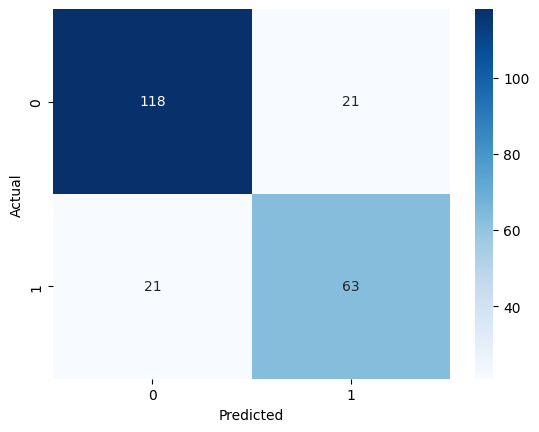

In [ ]:
# Logistic regression
logreg = LogisticRegression(max_iter=20000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

# Print confusion matrix and model scores
logreg_cm = confusion_matrix(y_test, y_pred)
logreg_acc = accuracy_score(y_test, y_pred)
logreg_prec = precision_score(y_test, y_pred)
logreg_recall = recall_score(y_test, y_pred)
logreg_f1 = f1_score(y_test, y_pred)

print('Logistic Regression Results:')
print('Confusion Matrix:\n', logreg_cm)
print('Accuracy:', logreg_acc)
print('Precision:', logreg_prec)
print('Recall:', logreg_recall)
print('F1 Score:', logreg_f1)

#Display Confusion Matrix with labels
sns.heatmap(logreg_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Logreg model summary
logreg_coefs = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': logreg.coef_[0]})
logreg_coefs.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
30,Ticket Type_STON/O,1.446646
12,Pclass_Upper,0.956901
11,Pclass_Middle,0.849705
17,Ticket Type_C,0.708287
3,Cabin_bool,0.669523
4,Any Family,0.598663
22,Ticket Type_LINE,0.479684
29,Ticket Type_SOTON/OQ,0.370423
28,Ticket Type_SOTON/O.Q.,0.363239
18,Ticket Type_C.A.,0.317024


XGBoost Results:
Confusion Matrix:
 [[130   9]
 [ 21  63]]
Accuracy: 0.8654708520179372
Precision: 0.875
Recall: 0.75
F1 Score: 0.8076923076923077


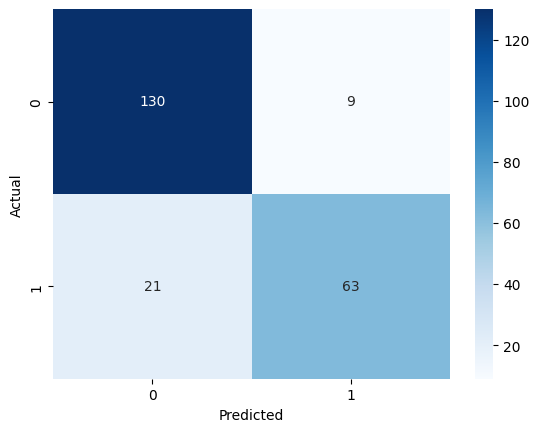

In [ ]:
# XGBoost model

xgb = XGBClassifier()

xgb = XGBClassifier(objective='binary:logistic', random_state=0)

cv_params = {'max_depth': [6,7,8,9],
             'min_child_weight': [4,5,6],
             'learning_rate': [0.02,0.05,0.1],
             'n_estimators': [100,115,130]
             }
scoring = ['accuracy', 'precision', 'recall', 'f1']

xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='f1')


xgb_cv.fit(X_train, y_train)
y_pred = xgb_cv.predict(X_test)

# Print confusion matrix and model scores
xgb_cm = confusion_matrix(y_test, y_pred)
xgb_acc = accuracy_score(y_test, y_pred)
xgb_prec = precision_score(y_test, y_pred)
xgb_recall = recall_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)

print('XGBoost Results:')
print('Confusion Matrix:\n', xgb_cm)
print('Accuracy:', xgb_acc)
print('Precision:', xgb_prec)
print('Recall:', xgb_recall)
print('F1 Score:', xgb_f1)

# Display Confusion Matrix with labels
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

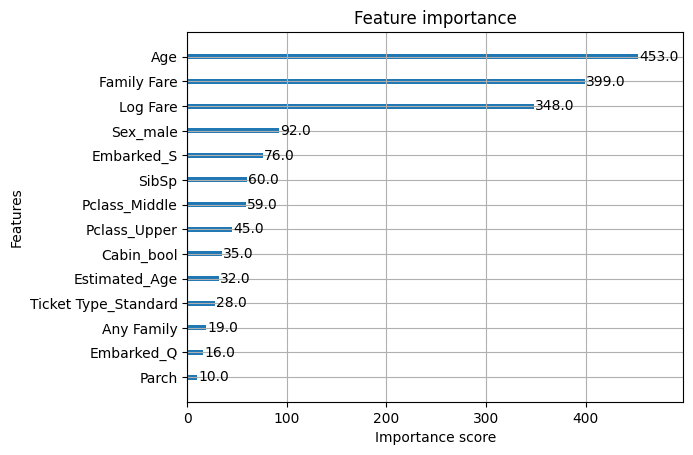

{'learning_rate': 0.05,
 'max_depth': 8,
 'min_child_weight': 5,
 'n_estimators': 130}

In [ ]:
plot_importance(xgb_cv.best_estimator_)
plt.show()
xgb_cv.best_params_

Random Forest Results:
Confusion Matrix:
 [[118  21]
 [ 23  61]]
Accuracy: 0.8026905829596412
Precision: 0.7439024390243902
Recall: 0.7261904761904762
F1 Score: 0.7349397590361446


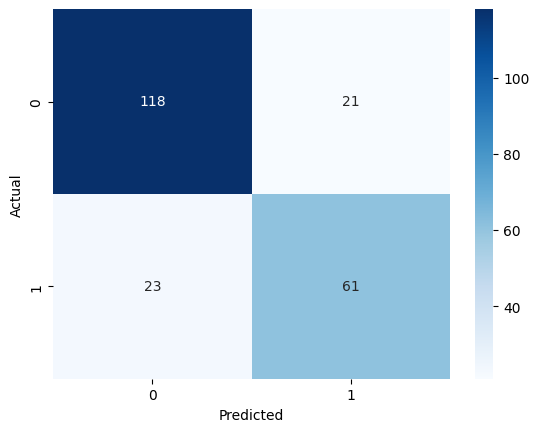

In [ ]:
# Random forest model

rf = RandomForestClassifier(random_state=0)

cv_params = {'max_depth': [3,5, None],
             'max_features': [1.0],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }

rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='f1')

rf_cv.fit(X_train, y_train)
y_pred = rf_cv.predict(X_test)

# Print confusion matrix and model scores
rf_cm = confusion_matrix(y_test, y_pred)
rf_acc = accuracy_score(y_test, y_pred)
rf_prec = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)

print('Random Forest Results:')
print('Confusion Matrix:\n', rf_cm)
print('Accuracy:', rf_acc)
print('Precision:', rf_prec)
print('Recall:', rf_recall)
print('F1 Score:', rf_f1)

# Display Confusion Matrix with labels
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Compare models
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Random Forest'],
    'Accuracy': [logreg_acc, xgb_acc, rf_acc],
    'Precision': [logreg_prec, xgb_prec, rf_prec],
    'Recall': [logreg_recall, xgb_recall, rf_recall],
    'F1 Score': [logreg_f1, xgb_f1, rf_f1]
})

models

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.811659,0.750000,0.75000,0.750000
1,XGBoost,0.865471,0.875000,0.75000,0.807692
2,Random Forest,0.802691,0.743902,0.72619,0.734940


In [ ]:
# Save best predictions on df_test to files

X_test, y = clean_titanic_data(df_test)
y_test_logreg = logreg.predict(X_test)
y_test_xgb = xgb_cv.predict(X_test)
y_test_rf = rf_cv.predict(X_test)

# Save y_test_xgb to csv
y_test_xgb.to_csv('y_test_xgb.csv')

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


KeyError: "['Survived'] not found in axis"